In [ ]:
import pandas as pd
import numpy as np
import joblib # Dùng để lưu scaler
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input

# 1. Đọc dữ liệu
# Đọc file, bỏ qua cột đầu tiên nếu nó là index hoặc không chứa dữ liệu số
df = pd.read_csv('../data/VCB_data.csv', index_col=0, parse_dates=True)

# KIỂM TRA: In ra các cột để xem có cột nào chứa văn bản không
print(df.dtypes) 

# Chỉ lấy các cột cần thiết và đảm bảo chúng là kiểu số
# Nếu 'Volume' hoặc các cột khác đang bị định dạng sai, lệnh này sẽ ép kiểu lại:
df[['Close', 'RSI', 'Volume']] = df[['Close', 'RSI', 'Volume']].apply(pd.to_numeric, errors='coerce')

# Xóa các dòng có giá trị NaN nếu có (do ép kiểu lỗi)
df.dropna(inplace=True)

# Bây giờ mới chọn features
features = df[['Close', 'RSI', 'Volume']]
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)

# 2. Chuẩn hóa và lưu scaler để dùng cho dự báo sau này
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)
joblib.dump(scaler, '../models/scaler.pkl')

# 3. Tạo dữ liệu đầu vào cho LSTM
def create_dataset(dataset, time_step=60):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), :])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)

# 4. Chia dữ liệu
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 5. Xây dựng mô hình
model = Sequential([
    Input(shape=(60, 3)),
    LSTM(50, return_sequences=True),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')

# 6. Huấn luyện
history = model.fit(X_train, y_train, epochs=50, batch_size=32, 
                    validation_data=(X_test, y_test), verbose=1)

# Lưu mô hình đã train
model.save('../models/vcb_lstm_model.h5')
print("Huấn luyện xong và đã lưu mô hình!")

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
RSI       float64
MA10      float64
MA20      float64
MA50      float64
MACD      float64
dtype: object
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0573 - val_loss: 0.0032
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0083 - val_loss: 0.0040
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0064 - val_loss: 0.0018
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0055 - val_loss: 0.0015
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0050 - val_loss: 0.0015
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0047 - val_loss: 0.0014
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0043 - val_loss: 0.0015
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0038 - val_loss: 0.0014
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0037 - val_loss: 0.0014
Epoch 10/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s

Huấn luyện xong và đã lưu mô hình!


Loss (Train): Giảm dần ổn định từ 0.0573 xuống 0.0014.
Val_loss (Validation): Giảm ổn định từ 0.0032 xuống 0.0014 (với những thời điểm chạm đáy thấp nhất ở mức 6.8423e-04).
Sự hội tụ: Sự chênh lệch giữa loss và val_loss rất nhỏ, chứng tỏ mô hình không bị Overfitting và đã học được xu hướng từ dữ liệu.

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


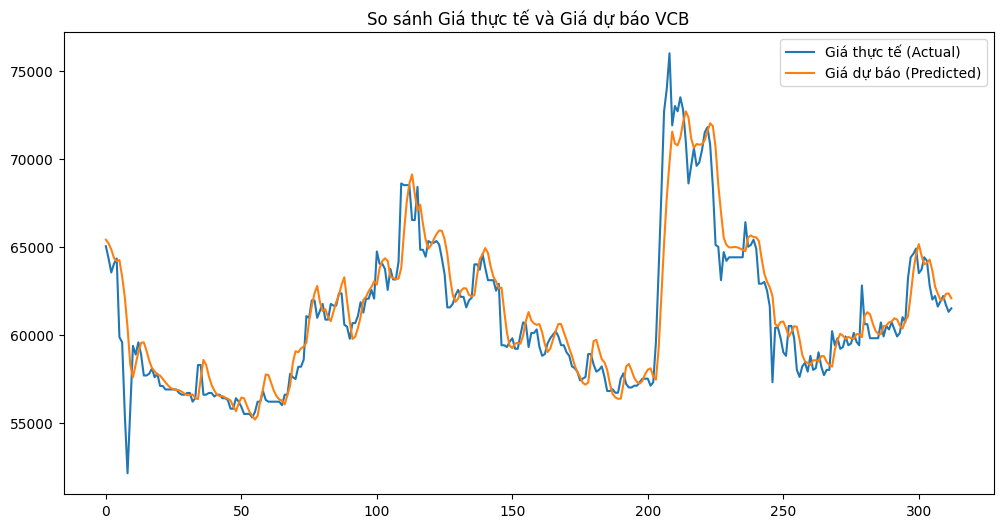

In [2]:
import matplotlib.pyplot as plt

# 1. Dự báo trên tập Test
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# 2. Đảo ngược chuẩn hóa (Inverse Transform)
# Lưu ý: Vì scaler được fit trên 3 cột (Close, RSI, Volume), 
# khi inverse_transform ta phải tạo mảng giả gồm 3 cột.
def dummy_inverse(data, scaler):
    dummy = np.zeros((len(data), 3))
    dummy[:, 0] = data[:, 0] # Đưa giá dự báo vào cột 0 (Close)
    return scaler.inverse_transform(dummy)[:, 0]

# Chuyển về giá thực tế (VND)
y_test_real = dummy_inverse(y_test.reshape(-1, 1), scaler)
test_predict_real = dummy_inverse(test_predict, scaler)

# 3. Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
plt.plot(y_test_real, label='Giá thực tế (Actual)')
plt.plot(test_predict_real, label='Giá dự báo (Predicted)')
plt.title('So sánh Giá thực tế và Giá dự báo VCB')
plt.legend()
plt.show()

Độ trễ thời gian (Time Lag): Đây là đặc điểm kinh điển của các mô hình LSTM khi dự báo chứng khoán. Bạn có thể thấy đường Giá dự báo (màu cam) dường như "đi sau" đường Giá thực tế (màu xanh) một chút. Điều này xảy ra do mô hình có xu hướng dự báo giá của ngày mai dựa nhiều vào giá của ngày hôm nay, tạo ra hiện tượng trễ pha.
Khả năng bắt sóng: Mô hình của bạn bắt rất tốt các đợt sóng tăng/giảm lớn (ví dụ đoạn từ chỉ số 210 đến 230). Điều này chứng tỏ mô hình đã học được mối quan hệ giữa biến động giá và các chỉ báo kỹ thuật (RSI, Volume) mà bạn đã cung cấp.
Điểm yếu cần khắc phục: Tại những "đỉnh" (peaks) hoặc "đáy" (valleys) đột ngột, mô hình thường không dự báo được mức giá cao nhất hoặc thấp nhất. Đây là rào cản lớn nhất của các mô hình dự báo định lượng trên thị trường tài chính vì các điểm đảo chiều thường do tin tức (news-driven) chứ không chỉ do dữ liệu lịch sử.